# Model training using synthetic data - October 2025

## Fase 1: Importaciones y Métricas Personalizadas

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Librerías del modelo de Keras
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import SGD, Adam
from keras import callbacks
import tensorflow.keras.backend as K
from keras.models import load_model

# --- MÉTRICAS PERSONALIZADAS (de tu notebook original) ---
# Estas métricas son excelentes para evaluar el rendimiento
# en problemas de clasificación como el nuestro.

def recall_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + K.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + K.epsilon()))

print("Fase 1 completada: Librerías importadas y métricas definidas.")

Fase 1 completada: Librerías importadas y métricas definidas.


## Fase 2: Carga y Preparación de Datos

In [3]:
# --- Carga de los nuevos datasets ---
# Asegúrate de que las rutas a tus archivos sean correctas
try:
    X = np.load('datasets/features_150k_17_11_25.csv.npy')
    y = np.load('datasets/labels_150k_17_11_25.csv.npy')
    print("Archivos CSV cargados exitosamente.")
except FileNotFoundError:
    print("Error: No se encontraron los archivos del dataset. Verifica las rutas.")
    # Detener la ejecución si no se encuentran los archivos
    assert False, "Deteniendo ejecución por falta de archivos."


# --- Separación en Train/Test ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% para pruebas
    random_state=42 # Para reproducibilidad
)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_test: {y_test.shape}")


# --- Normalización de Features (CORREGIDA)---
# Calculamos la media y std SOLO del set de entrenamiento
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# >> INICIO DE LA CORRECCIÓN <<
# Se añade un valor muy pequeño (epsilon) a la desviación estándar 
# para evitar la división por cero en columnas con varianza nula.
epsilon = 1e-7
X_train = (X_train - mean) / (std + epsilon)
X_test = (X_test - mean) / (std + epsilon)

# Verificamos si hay algún valor NaN después de la normalización
if np.isnan(X_train).any():
    print("\\nAlerta: Se encontraron valores NaN en X_train después de la normalización.")
else:
    print("\\nNormalización segura completada. No se encontraron NaNs.")
# >> FIN DE LA CORRECCIÓN <<

# Convertir a arrays de numpy para Keras
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train).astype('float32')
y_test = np.array(y_test).astype('float32')

print("\\nFase 2 completada: Datos cargados, separados y normalizados correctamente.")

Archivos CSV cargados exitosamente.
Forma de X_train: (120000, 244)
Forma de y_train: (120000, 1649)
Forma de X_test: (30000, 244)
Forma de y_test: (30000, 1649)
\nNormalización segura completada. No se encontraron NaNs.
\nFase 2 completada: Datos cargados, separados y normalizados correctamente.


In [4]:
# --- Evaluación Final en el Set de Prueba ---
from keras.models import load_model

# Cargar el mejor modelo que acabamos de guardar
model = load_model(
    'sonar_model_multiobjeto.h5', 
    custom_objects={'f1_m': f1_m, 'precision_m': precision_m, 'recall_m': recall_m}
)
print("Modelo 'sonar_model_multiobjeto.h5' cargado.")

print("\nEvaluando el modelo final en el conjunto de prueba:")
score = model.evaluate(X_test, y_test, verbose=1)

print(f"\nResultados en el Test Set:")
print(f"  Pérdida (Loss): {score[0]:.4f}")
print(f"  F1-Score: {score[1]:.4f}")
print(f"  Precision: {score[2]:.4f}")
print(f"  Recall: {score[3]:.4f}")

# --- Ejemplo de Predicción ---
print("\nEjemplo de predicción en una muestra del test set:")
# Hacemos la predicción sobre todo el set de prueba
y_pred_probs = model.predict(X_test)

# Definimos un umbral para decidir si un cuadrante está "activo"
umbral_prediccion = 0.35
y_pred = (y_pred_probs > umbral_prediccion).astype(int)

for i in range(5):
    # Elegimos una muestra al azar para comparar
    indice_ejemplo = np.random.randint(0, len(y_test))
    
    cuadrantes_reales = np.where(y_test[indice_ejemplo] == 1)[0]
    cuadrantes_predichos = np.where(y_pred[indice_ejemplo] == 1)[0]
    
    print(f"\n--- Muestra #{indice_ejemplo} ---")
    print(f"Cuadrantes Reales:     {cuadrantes_reales}")
    print(f"Cuadrantes Predichos:  {cuadrantes_predichos}")

Modelo 'sonar_model_multiobjeto.h5' cargado.

Evaluando el modelo final en el conjunto de prueba:


2025-11-17 17:46:00.753348: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.


938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_m: 0.4608 - loss: 0.0039 - precision_m: 0.6566 - recall_m: 0.3576

Resultados en el Test Set:
  Pérdida (Loss): 0.0039
  F1-Score: 0.4608
  Precision: 0.6566
  Recall: 0.3576

Ejemplo de predicción en una muestra del test set:
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


2025-11-17 17:46:05.833712: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 197880000 exceeds 10% of free system memory.



--- Muestra #1504 ---
Cuadrantes Reales:     [460 461 462]
Cuadrantes Predichos:  [430 461 462]

--- Muestra #9713 ---
Cuadrantes Reales:     [ 938  999 1029]
Cuadrantes Predichos:  [937 999]

--- Muestra #6002 ---
Cuadrantes Reales:     [584]
Cuadrantes Predichos:  [584 585]

--- Muestra #16111 ---
Cuadrantes Reales:     [637]
Cuadrantes Predichos:  [575 637]

--- Muestra #8189 ---
Cuadrantes Reales:     [736 801 869 917]
Cuadrantes Predichos:  [735 785 801 869]


## Visualizacion de predicciones vs etiquetas reales

Dibujar punto en X=-91.0, Y=51.0
Dibujar punto en X=-55.0, Y=51.0
Dibujar punto en X=-49.0, Y=51.0
Dibujar punto en X=-55.0, Y=51.0
Dibujar punto en X=-49.0, Y=51.0


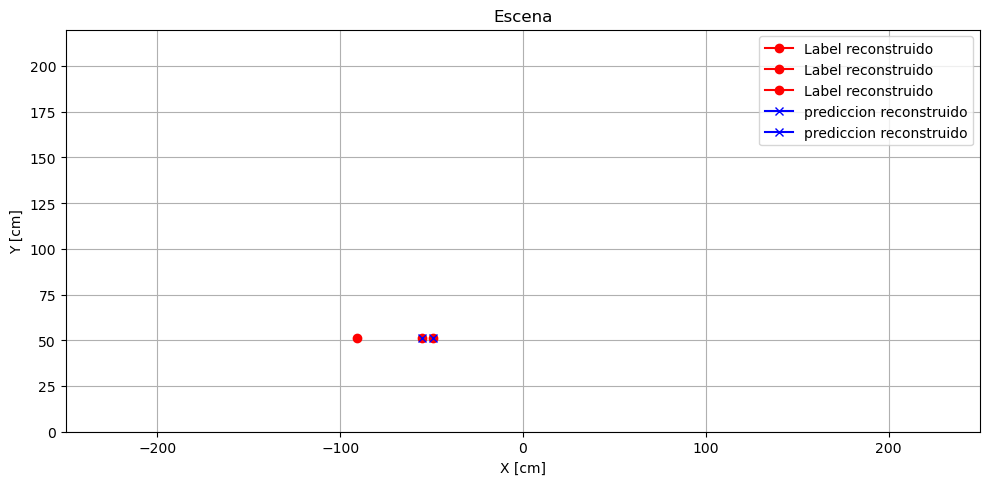

In [42]:
import seaborn as sns

# Cargamos el mapa de cuadarntes para reconstruir la posicion X, Y

mapa_centroides = np.load('mapa_de_cuadrantes.npy')
0
fig, (ax1) = plt.subplots(1, 1, figsize=(10, 8))

sample_number = 21
labels = y_test[sample_number]
predicciones = y_pred[sample_number]

for label in np.where(labels == 1)[0]:
    coordenadas = mapa_centroides[label]
    print(f"Dibujar punto en X={coordenadas[0]}, Y={coordenadas[1]}")
    ax1.plot(coordenadas[0],coordenadas[1] , color='red', marker='o', alpha=1, label='Label reconstruido')

for prediccion in np.where(predicciones == 1)[0]:
    coordenadas = mapa_centroides[prediccion]
    print(f"Dibujar punto en X={coordenadas[0]}, Y={coordenadas[1]}")
    ax1.plot(coordenadas[0],coordenadas[1] , color='blue', marker='x', alpha=1, label='prediccion reconstruido')


ax1.set_title(f"Escena")
ax1.set_xlabel("X [cm]"); ax1.set_ylabel("Y [cm]")
ax1.set_xlim(-250, 250); ax1.set_ylim(0, 220)
ax1.set_aspect('equal', adjustable='box'); ax1.grid(True); ax1.legend()

plt.tight_layout(); plt.show()